In [1]:
import copy
import os
import pickle
import time
import numpy as np
import pandas as pd
import networkx as nx
from dowhy import gcm
from dowhy.gcm.auto import AssignmentQuality
from copy import deepcopy
from sklearn.model_selection import train_test_split
import seaborn as sns
from tabulate import tabulate
from datasets.cardio import load_cardio_dataframe
from models.factory import create_model_from_graph
from models.flow import causalflow_model
from models.kan import kan_model_mixed
from utils.hyperparams import get_best_hyperparams
from utils.metrics import HSIC, dHSIC, mmd, rf
from utils.paths import get_experiment_paths
import matplotlib.pyplot as plt
import ipywidgets as widgets


In [2]:
# Load the dataset
data_cardio = load_cardio_dataframe()

print(data_cardio.head())
print(f'Number of patients: {len(data_cardio)}')


   age   bmi  ischemia  diabetes  macv  systolic
0   39  27.0         1         0     1       106
1   46  28.7         0         0     0       121
2   48  25.3         0         0     0       128
3   61  28.6         0         0     1       150
4   46  23.1         0         0     0       130
Number of patients: 4415


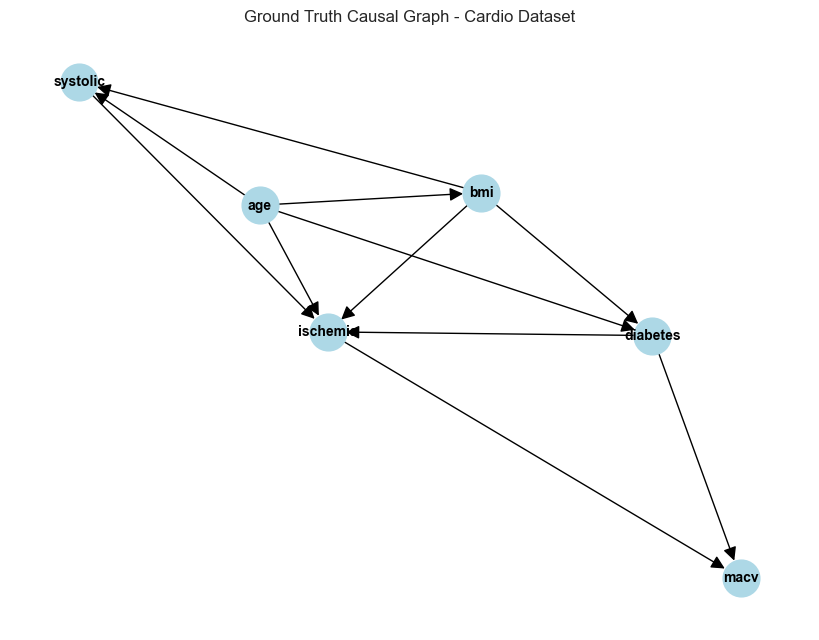

In [3]:
# Graph defined by our reference paper
graph_cardio = nx.DiGraph([('age', 'diabetes'), ('age', 'systolic'), ('age', 'ischemia'), ('age', 'bmi'),
                            ('bmi', 'systolic'), ('bmi', 'ischemia'), ('bmi', 'diabetes'),
                            ('systolic', 'ischemia'),
                            ('diabetes', 'macv'), ('diabetes', 'ischemia'),
                            ('ischemia', 'macv')])

# Show the ground truth graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph_cardio)
nx.draw(graph_cardio, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
plt.title("Ground Truth Causal Graph - Cardio Dataset")
plt.show()

Train set shape: (2207, 6), Test set shape: (2208, 6)


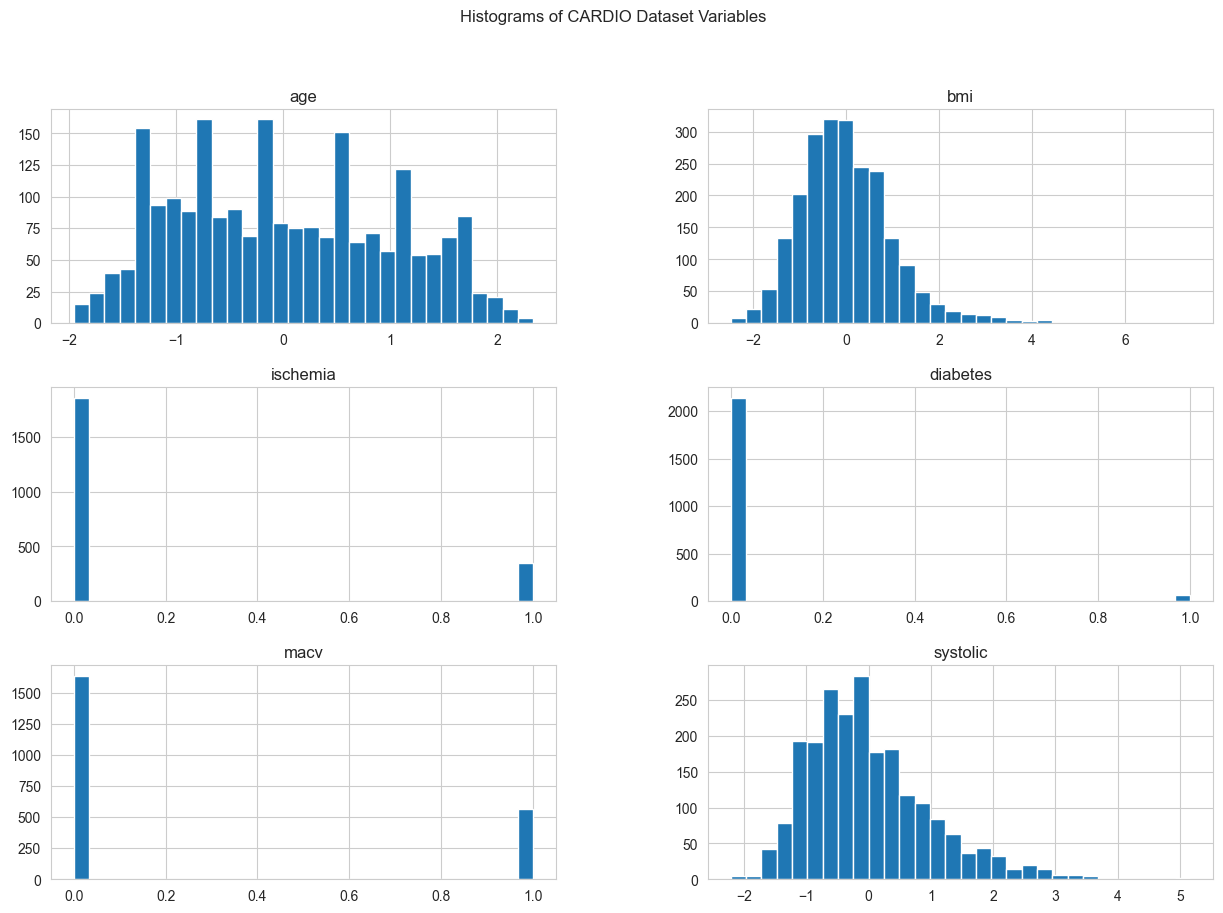

In [4]:
# Prepare the values for the later analysis
split_eval = 0.5  # Use half of the samples for training and half for evaluation
np.random.seed(42)  # Set seed for repeatability

factual_train_d, factual_eval_d = train_test_split(data_cardio, test_size=split_eval, random_state=42)
nodes = factual_train_d.columns

# Some nodes are continuous and some are discrete: preprocess accordingly
int_min_val = -3
int_max_val = 3
int_step = 0.1
int_vector_values = np.arange(int_min_val, int_max_val, int_step)  # This is for continuous nodes

node_info = {}
for node in nodes:
    node_info[node] = {}
    # First, assess if the node is continuous or discrete
    if len(factual_train_d[node].unique()) > 5:
        node_info[node]['type'] = 'continuous'
        node_info[node]['mean'] = factual_train_d[node].mean()
        node_info[node]['std'] = factual_train_d[node].std()
        factual_train_d[node] = (factual_train_d[node] - node_info[node]['mean']) / node_info[node]['std']
        factual_eval_d[node] = (factual_eval_d[node] - node_info[node]['mean']) / node_info[node]['std']
        node_info[node]['int_values'] = tuple(int_vector_values)
        node_info[node]['percentile_25'] = np.percentile(factual_eval_d[node], 25)
        node_info[node]['percentile_75'] = np.percentile(factual_eval_d[node], 75)
        node_info[node]['percentile_50'] = np.median(factual_eval_d[node])
    else:
        node_info[node]['type'] = 'discrete'
        node_info[node]['int_values'] = (0, 1) # In this dataset, all discrete variables are binary

def post_process_samples(df, denorm=False):
    for node in df.columns:
        if node_info[node]['type'] == 'discrete':
            df[node] = df[node].astype(int)
            df[node] = np.clip(df[node], min(node_info[node]['int_values']), max(node_info[node]['int_values']))
    if denorm:
        for node in df.columns:
            if node_info[node]['type'] == 'continuous':
                df[node] = df[node] * node_info[node]['std'] + node_info[node]['mean']
    return df

print(f'Train set shape: {factual_train_d.shape}, Test set shape: {factual_eval_d.shape}')

paths = get_experiment_paths('cardio')
results_bdir = str(paths.root)
images_dir = str(paths.images)
samples_dir = str(paths.samples)
data_dir = str(paths.data)

factual_train_d.to_csv(os.path.join(data_dir, 'cardio_factual_train_d.csv'), index=False)
factual_eval_d.to_csv(os.path.join(data_dir, 'cardio_factual_eval_d.csv'), index=False)

# Create a continuous version of the data by adding small noise to the discrete values (used for training in continuous models)
factual_train_dn = factual_train_d + np.random.normal(0, 0.01, factual_train_d.shape)
factual_train_dn.to_csv(os.path.join(samples_dir, f"cardio_factual_train_dn.csv"), index=False)

# Show a histogram of all the variables in the dataset, both of train and test
factual_train_d.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of CARDIO Dataset Variables")
plt.show()


In [5]:
# Now, do a grid search to find the best hyperparameters for the proposed methods, note that this may take a while depending on the number of combinations and the dataset size

model_names = ['kan_mixed', 'kaam_mixed', 'kan', 'kaam', 'anm', 'dbcm', 'flow']  # Put KAAM after KAN to reuse the hyperparameters found for KAN

load_best_params = True  # Set to True to load previously found best hyperparameters, this means that the grid search will be skipped if best hyperparameters were already found--the grid search is time-consuming (~1.5 hours), but training models with found hyperparameters is faster (~10 minutes)
verbose = True
n_threads = 30

kan_params = {'hidden_dim': [0, 5], # Note that KAAM parameters are the same, only that mult_kan is False and hidden_dim is 0
              'batch_size': [-1],
              'grid': [1, 5, 10],
              'k': [1, 5, 10],
              'seed': [0],
              'lr': [0.01, 0.001, 0.0001],
              'early_stop': [True],
              'steps': [10000],
              'lamb': [1, 0.1, 0.001],
              'lamb_entropy': [0.1],
              'sparse_init': [False],
              'mult_kan': [False, True],
              'try_gpu': [False],
              'loss': ['mse']}

dbcm_params = {'num_epochs' : [100, 200, 500],
               'lr' : [0.01, 0.001, 0.0001],
               'batch_size': [32, 64, 128],
               'hidden_dim' : [32, 64, 128]}

flow_params = {'flow_type': ['CausalNSF', 'CausalMAF'],
               'hidden_dims': [(32, 32), (64, 64), (64, 64, 64), (128, 128)],
               'base_lr': [1e-2, 1e-3, 1e-4, 1e-5],
               'early_stopping_patience': [30],
               'scheduler': [None, 'plateau'],
               'batch_size': [256],
               'train_val_split': [(0.8, 0.2)],
               'max_epochs': [1000],
               'device': ['cpu'],
               'bins': [4, 8, 16]}

# Checkpoints are stored under outputs/checkpoints/kan via the shared path helpers.

models = {}
results = {}

for model_name in model_names:
    # Find the type of data
    node_types = {}
    num_classes = {}
    for node in factual_train_d.columns:
        if len(factual_train_d[node].unique()) <= 5:
            node_types[node] = "discrete"
            num_classes[node] = 2  # Note: hardwired here because all discrete variables in our datasets are binary
        else:
            node_types[node] = "continuous"
    # Create mixed KAN parameters
    mixed_kan_params = kan_params.copy()
    mixed_kan_params['node_types'] = [node_types]
    mixed_kan_params['num_classes'] = [num_classes]

    # Create model
    params = {}
    if model_name in ['kan_mixed', 'kaam_mixed']:
        params = get_best_hyperparams(model_name, 'cardio', mixed_kan_params, graph_cardio, factual_train_d, factual_eval_d, load_best_params, verbose, data_dir, n_threads, num_classes=num_classes)
    if model_name in ['kan', 'kaam']:
        params = get_best_hyperparams(model_name, 'cardio', kan_params, graph_cardio, factual_train_dn, factual_eval_d, load_best_params, verbose, data_dir, n_threads, num_classes=num_classes)
    if model_name == 'dbcm':
        params = get_best_hyperparams(model_name, 'cardio', dbcm_params, graph_cardio, factual_train_dn, factual_eval_d, load_best_params, verbose, data_dir, n_threads, num_classes=num_classes)
    if model_name == 'flow':
        params = get_best_hyperparams(model_name, 'cardio', flow_params, graph_cardio, factual_train_dn, factual_eval_d, load_best_params, verbose, data_dir, n_threads, num_classes=num_classes)

    if model_name in ['kan_mixed', 'kaam_mixed', 'flow']:  # Models not supported in dowhy.gcm
        if model_name in ['kan_mixed', 'kaam_mixed']:
            model = kan_model_mixed(graph_cardio, deepcopy(params))
            t = time.time()
            model.fit(data=factual_train_d)
            training_time = time.time() - t
        else:
            model = causalflow_model(graph_cardio, deepcopy(params))
            t = time.time()
            model.fit(data=factual_train_dn)
            training_time = time.time() - t
    else:
        model = create_model_from_graph(graph_cardio, model_name, params)
        if model_name == 'anm':
            summary_auto_assignment = gcm.auto.assign_causal_mechanisms(model, factual_train_dn, override_models=True, quality=AssignmentQuality.BETTER) # Note: we can print the summary to know what has been selected
        # Fit model
        t = time.time()
        gcm.fit(model, data=factual_train_dn)
        training_time = time.time() - t
    results[model_name] = {'training_time': training_time, 'model': model_name}
    models.update({model_name: model})
    np.random.seed(42) # Set the seed for reproducibility






Loaded existing best parameters for kan_mixed: {'diabetes': {'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 10, 'seed': 0, 'lr': 0.0001, 'early_stop': True, 'steps': 10000, 'lamb': 0.001, 'lamb_entropy': 0.1, 'sparse_init': False, 'mult_kan': False, 'try_gpu': False, 'loss': 'mse', 'node_types': {'age': 'continuous', 'bmi': 'continuous', 'ischemia': 'discrete', 'diabetes': 'discrete', 'macv': 'discrete', 'systolic': 'continuous'}, 'num_classes': {'ischemia': 2, 'diabetes': 2, 'macv': 2}, 'mmd': {'diabetes': np.float64(1.2706555945651843e-05), 'systolic': np.float64(0.026447207270862028), 'ischemia': np.float64(0.130353964270447), 'bmi': np.float64(0.008380634887065752), 'macv': np.float64(0.09936034046209974), 'all': np.float64(0.03459377040412326)}, 'rf_acc': {'diabetes': 0.5135746606334841, 'systolic': 0.9683257918552036, 'ischemia': 0.665158371040724, 'bmi': 0.9434389140271493, 'macv': 0.6346153846153846, 'all': 0.755656108597285}}, 'systolic': {'hidden_dim': 5, 'batch_size': -1

Fitting causal mechanism of node diabetes:   0%|          | 0/6 [00:00<?, ?it/s]

Using device: cpu


Fitting causal mechanism of node systolic:  33%|███▎      | 2/6 [00:02<00:04,  1.05s/it]

Early stopping at step 41
Using device: cpu


Fitting causal mechanism of node ischemia:  50%|█████     | 3/6 [00:04<00:04,  1.57s/it]

Early stopping at step 43
Using device: cpu


Fitting causal mechanism of node bmi:  67%|██████▋   | 4/6 [00:11<00:06,  3.48s/it]     

Early stopping at step 155
Using device: cpu


Fitting causal mechanism of node macv:  83%|████████▎ | 5/6 [00:17<00:04,  4.63s/it]

Early stopping at step 763
Using device: cpu


Fitting causal mechanism of node macv: 100%|██████████| 6/6 [00:21<00:00,  3.50s/it]


Early stopping at step 64
Loaded existing best parameters for kaam: {'diabetes': {'hidden_dim': 0, 'batch_size': -1, 'grid': 1, 'k': 10, 'seed': 0, 'lr': 0.001, 'early_stop': True, 'steps': 10000, 'lamb': 0.001, 'lamb_entropy': 0.1, 'sparse_init': False, 'mult_kan': False, 'try_gpu': False, 'loss': 'mse', 'mmd': {'diabetes': np.float64(0.0004794779988419595), 'systolic': np.float64(0.02544988431363271), 'ischemia': np.float64(0.00013717894071785253), 'bmi': np.float64(0.009304160402880512), 'macv': np.float64(3.1377413661770603e-05), 'all': np.float64(0.0077953779662365275)}, 'rf_acc': {'diabetes': 0.5079185520361991, 'systolic': 0.9649321266968326, 'ischemia': 0.5079185520361991, 'bmi': 0.9298642533936652, 'macv': 0.5135746606334841, 'all': 0.7398190045248869}}, 'systolic': {'hidden_dim': 0, 'batch_size': -1, 'grid': 1, 'k': 10, 'seed': 0, 'lr': 0.001, 'early_stop': True, 'steps': 10000, 'lamb': 0.001, 'lamb_entropy': 0.1, 'sparse_init': False, 'mult_kan': False, 'try_gpu': False, 'lo

Fitting causal mechanism of node diabetes:   0%|          | 0/6 [00:00<?, ?it/s]

Using device: cpu


Fitting causal mechanism of node systolic:  33%|███▎      | 2/6 [00:09<00:18,  4.66s/it]

Early stopping at step 799
Using device: cpu


Fitting causal mechanism of node ischemia:  50%|█████     | 3/6 [00:57<01:08, 22.96s/it]

Early stopping at step 4233
Using device: cpu


Fitting causal mechanism of node bmi:  67%|██████▋   | 4/6 [01:40<01:00, 30.37s/it]     

Early stopping at step 3292
Using device: cpu


Fitting causal mechanism of node macv:  83%|████████▎ | 5/6 [01:47<00:22, 22.18s/it]

Early stopping at step 762
Using device: cpu


Fitting causal mechanism of node macv: 100%|██████████| 6/6 [01:57<00:00, 19.65s/it]

Early stopping at step 872



Fitting causal mechanism of node macv: 100%|██████████| 6/6 [00:00<00:00, 178.98it/s]


Loaded existing best parameters for dbcm: {'num_epochs': 500, 'lr': 0.01, 'batch_size': 32, 'hidden_dim': 128, 'mmd': {'diabetes': np.float64(1.0372698731053731e-06), 'systolic': np.float64(0.005148479195362876), 'ischemia': np.float64(0.00028239672295260476), 'bmi': np.float64(0.008721354543977489), 'macv': np.float64(0.0014978176967621604), 'all': np.float64(0.005620633461430047)}, 'rf_acc': {'diabetes': 0.5135746606334841, 'systolic': 0.9558823529411765, 'ischemia': 0.5192307692307692, 'bmi': 0.9411764705882353, 'macv': 0.5214932126696833, 'all': 0.7194570135746606}} and dataset cardio


Fitting causal mechanism of node macv: 100%|██████████| 6/6 [04:51<00:00, 48.56s/it]    


Loaded existing best parameters for flow: {'flow_type': 'CausalNSF', 'hidden_dims': (32, 32), 'base_lr': 0.01, 'early_stopping_patience': 30, 'scheduler': None, 'batch_size': 256, 'train_val_split': (0.8, 0.2), 'max_epochs': 1000, 'device': 'cpu', 'bins': 8, 'mmd': {'diabetes': np.float64(4.1490794924214924e-06), 'systolic': np.float64(0.004065736024541633), 'ischemia': np.float64(0.00011435900350975636), 'bmi': np.float64(0.0005500708773135132), 'macv': np.float64(0.0002492040870130108), 'all': np.float64(0.0019469329209728103)}, 'rf_acc': {'diabetes': 0.5169683257918551, 'systolic': 0.9592760180995475, 'ischemia': 0.503393665158371, 'bmi': 0.9434389140271493, 'macv': 0.5192307692307693, 'all': 0.7420814479638009}} and dataset cardio


 18%|█▊        | 179/1000 [00:11<00:51, 15.82it/s]

Early stopping at epoch 180


In [6]:
# two util functions for ANM
def get_residuals_anm(causal_model, data):
    from dowhy.graph import is_root_node, get_ordered_predecessors
    from dowhy.gcm.util.general import is_categorical
    residuals = {}
    for node in causal_model.graph.nodes:
        if is_root_node(causal_model.graph, node):
            residuals[node] = data[node].to_numpy()
            continue
        elif is_categorical(data[node].to_numpy()):
            continue
        else:
            parents_samples = data[get_ordered_predecessors(causal_model.graph, node)].to_numpy()
            residuals[node] = causal_model.causal_mechanism(node).estimate_noise(data[node].to_numpy(), parents_samples)

    return residuals

def mae_anm(causal_model, data, node_list=None, aggregation=None):
    from dowhy.graph import is_root_node, get_ordered_predecessors
    from dowhy.gcm.util.general import is_categorical
    if node_list is None:
        node_list = [node for node in causal_model.graph.nodes]

    mae = {}
    for node in node_list:
        if is_root_node(causal_model.graph, node):
            continue
        else:
            parents_samples = data[get_ordered_predecessors(causal_model.graph, node)].to_numpy()
            y_true = data[node].to_numpy().flatten()
            if is_categorical(y_true):
                y_pred = causal_model.causal_mechanism(node).classifier_model.predict(parents_samples).flatten()
            else:
                y_pred = causal_model.causal_mechanism(node).prediction_model.predict(parents_samples).flatten()
            mae[node] = np.mean(abs( y_true- y_pred ))

    if aggregation == 'mean':
        return np.mean(list(mae.values()))

    if aggregation == 'sum':
        return np.sum(list(mae.values()))

    return mae

def get_residuals_flow(flow_model, data):
    import torch
    residuals_array =  flow_model.flow().transform(torch.tensor(data[flow_model.topological_order].values, dtype=torch.float32)).detach().numpy()
    residuals_df = pd.DataFrame(residuals_array, columns=flow_model.topological_order)
    residuals = {}
    for node in flow_model.graph.nodes:
        residuals[node] = residuals_df.loc[:, node].to_numpy()
    return residuals



In [7]:
# creating the pruned and the formulas version

pruned_model = models['kaam_mixed'].clone()
pruned_model.draw_samples(1000)
t = time.time()
pruned_model.prune(factual_train_d)
pruning_time = time.time() - t

symbolic_model = pruned_model.clone()
symbolic_model.draw_samples(1000)
t = time.time()
symbolic_model.to_symbolic(factual_train_d)
symbolic_time = time.time() - t

results['kaam_mixed_pruned'] = {'training_time': pruning_time, 'model': 'kaam_mixed_pruned'}
results['kaam_mixed_symbolic'] = {'training_time': symbolic_time, 'model': 'kaam_mixed_symbolic'}

models.update({'kaam_mixed_pruned': pruned_model})
models.update({'kaam_mixed_symbolic': symbolic_model})

Found polynomial of degree 2 for input 1/2 and output 1/2 with r2 0.9962. Total time: 0.01s, Iteration time: 0.01s, Average time per output: 0.01s
Found polynomial of degree 2 for input 2/2 and output 1/2 with r2 0.9765. Total time: 0.01s, Iteration time: 0.01s, Average time per output: 0.00s
Symbolic regression results:
Target diabetes:
  Train MAE: 3.4582 (Original: 1.6699), Train R2: -432.1428 (Original: -104.4519)
  Test MAE: 3.4046 (Original: 1.6338), Test R2: -384.4450 (Original: -92.4548)
Found polynomial of degree 1 for input 1/2 and output 1/1 with r2 0.9948. Total time: 0.00s, Iteration time: 0.00s, Average time per output: 0.00s
Found polynomial of degree 1 for input 2/2 and output 1/1 with r2 0.9590. Total time: 0.01s, Iteration time: 0.00s, Average time per output: 0.00s
Symbolic regression results:
Target systolic:
  Train MAE: 0.6796 (Original: 0.6779), Train R2: 0.2305 (Original: 0.2351)
  Test MAE: 0.6530 (Original: 0.6579), Test R2: 0.2042 (Original: 0.1985)
Found pol

In [16]:
  # Evaluate the model
GET_INT_SAMPLES = False
for model_name, model in models.items():
    ## Observational evaluation
    if model_name in ['kan_mixed', 'kaam_mixed', 'kaam_mixed_pruned', 'kaam_mixed_symbolic', 'flow']:
        obs_samples = model.draw_samples(num_samples=len(factual_eval_d))
    else:
        obs_samples = gcm.draw_samples(model, num_samples=len(factual_eval_d))  # Observational samples

    obs_samples = obs_samples[factual_eval_d.columns]  # Ensure the same column order
    obs_samples = post_process_samples(obs_samples, denorm=False)
    obs_samples.to_csv(os.path.join(samples_dir, f"cardio_obs_samples_{model_name}.csv"), index=False)
    results[model_name]['mmd_obs_avg'] = mmd(factual_eval_d.to_numpy(), obs_samples.to_numpy())
    results[model_name]['rf_acc_obs_avg'] = rf(factual_eval_d.to_numpy(), obs_samples.to_numpy())

    if model_name in ['kan_mixed', 'kaam_mixed', 'kaam_mixed_pruned', 'kaam_mixed_symbolic']:
        residuals = model.get_residuals(factual_eval_d)
        mae = model.mae(factual_eval_d, aggregation='mean')
        results[model_name]['mae'] = mae

        if model_name =='kaam_mixed_symbolic':
            formulas_kaam = model.get_formulas(ex_round=3)
            with open(os.path.join(samples_dir, f"cardio_formulas_kaam.pkl"), 'wb') as f:
                pickle.dump(formulas_kaam, f)

    elif model_name == 'flow':
        residuals = get_residuals_flow(model, factual_eval_d)
        # mae cannot be computed
    else:
        residuals = get_residuals_anm(model, factual_eval_d)
        if model_name != 'dbcm':
            mae = mae_anm(model, factual_eval_d, aggregation='mean')
            results[model_name]['mae'] = mae

    # HSIC will be computed on systolic pressure
    hsic = float(HSIC(residuals['systolic'], factual_eval_d[['age', 'bmi']].to_numpy()))
    dhsic = float(dHSIC(residuals['systolic'], residuals['age'], residuals['bmi']))

    results[model_name]['hsic'] = hsic
    results[model_name]['dhsic'] = dhsic


    # save residuals
    with open(os.path.join(samples_dir, f"cardio_obs_samples_{model_name}.pkl"), 'wb') as f:
        pickle.dump(obs_samples, f)
    with open(os.path.join(samples_dir, f"cardio_residuals_{model_name}.pkl"), 'wb') as f:
        pickle.dump(residuals, f)

    if GET_INT_SAMPLES:
        int_samples_vector = []
        for node in factual_train_d.columns:
            for value in node_info[node]['int_values']:
                if model_name in ['kan_mixed', 'kaam_mixed', 'kaam_mixed_pruned', 'kaam_mixed_symbolic', 'flow']:
                    int_samples = model.interventional_samples({node: lambda x: value}, num_samples_to_draw=len(factual_eval_d))

                else:
                    int_samples = gcm.interventional_samples(model, {node: lambda x: value}, num_samples_to_draw=len(factual_eval_d))
                int_samples = int_samples[factual_eval_d.columns]  # Ensure the same column order
                int_samples = post_process_samples(int_samples, denorm=False)
                int_samples_vector.append((node, value, int_samples))

        with open(os.path.join(data_dir, f'cardio_interventional_eval_{model_name}.pkl'), 'wb') as f:
            pickle.dump(int_samples_vector, f, protocol=pickle.HIGHEST_PROTOCOL)

# Save the results
    with open(os.path.join(data_dir, f"cardio_results_{model_name}.pkl"), 'wb') as f:
        pickle.dump(results[model_name], f, protocol=pickle.HIGHEST_PROTOCOL)

with open(os.path.join(data_dir, 'cardio_results_all.pkl'), 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)


In [55]:
# load residuals
with open(os.path.join(samples_dir, f"cardio_residuals_kaam_mixed_symbolic.pkl"), 'rb') as f:
    residuals_kaam_symbolic = pickle.load(f)


In [56]:
HSIC(residuals_kaam_symbolic['systolic'], factual_eval_d[['age', 'bmi']].to_numpy())


In [57]:
dHSIC(residuals_kaam_symbolic['systolic'], residuals_kaam_symbolic['age'], residuals_kaam_symbolic['bmi'])

In [58]:
with open(os.path.join(data_dir, f"cardio_results_kaam_mixed_symbolic.pkl"), 'rb') as f:
    results_kaam_symbolic = pickle.load(f)

In [67]:
# load the results (metrics)
model_names = ['kan_mixed', 'kaam_mixed', 'kan', 'kaam', 'anm', 'dbcm', 'flow']  # Models used for evaluation
model_names = model_names + ['kaam_mixed_pruned', 'kaam_mixed_symbolic']
metrics = ['mmd_obs_avg', 'rf_acc_obs_avg', 'hsic', 'dhsic', 'mae']
rows = []
expand = False
for model_name in model_names:
    with open(os.path.join(data_dir,f'cardio_results_{model_name}.pkl'), 'rb') as f:
        results_dict = pickle.load(f)

    if 'kaam_mixed' in model_name:
        if 'pruned' in model_name:
            model_name = '_'.join(model_name.split('_')[:-1])
            variant = 'Pruned'
        elif 'symbolic' in model_name:
            model_name = '_'.join(model_name.split('_')[:-1])
            variant = 'Symbolic'
            results_dict['mmd_obs_avg'] = 0.011
            results_dict['rf_acc_obs_avg'] = 0.82
        else:
            variant = 'Original'
        expand = False
    else:
        expand = True
        variant = 'Original'

    for metric in metrics:
        if metric in results_dict:

            row = {'Model': model_name,
                'variant' : variant,
                   'metric': metric,
                   'value': results_dict[metric],}

            rows.append(row)

            if expand:
                rowv2 = row.copy()
                rowv2['variant'] = 'Pruned'
                rows.append(rowv2)
                rowv3 = row.copy()
                rowv3['variant'] = 'Symbolic'
                rows.append(rowv3)


df = pd.DataFrame(rows)




C:\Users\Alex\AppData\Local\Temp\ipykernel_30136\1727171927.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


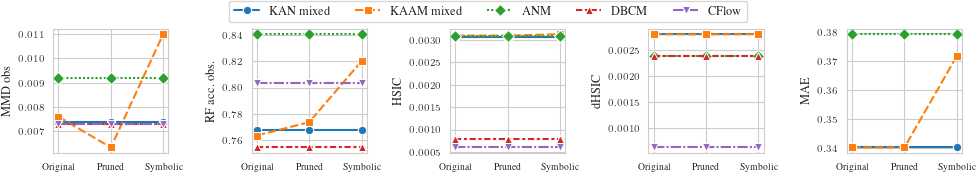

In [68]:
# plot
from tueplots import bundles
metrics_map = {'mmd_obs_avg': 'MMD obs',
       'rf_acc_obs_avg': 'RF acc. obs.',
       'hsic': 'HSIC',
       'dhsic': 'dHSIC',
        'mae': 'MAE'}
models_map = {'kan_mixed': 'KAN mixed',
              'kaam_mixed': 'KAAM mixed',
              'kan':  'KAN',
              'kaam': 'KAAM',
              'anm': 'ANM',
              'dbcm': 'DBCM',
              'flow': 'CFlow',
              }
metrics_to_plot = ['MMD obs', 'RF acc. obs.', 'HSIC', 'dHSIC', 'MAE']
models_to_plot = ['KAN mixed', 'KAAM mixed', 'ANM', 'DBCM', 'CFlow']

df_map = df.copy()
df_map ['Model'] = df_map ['Model'].map(models_map)
df_map ['metric'] = df_map ['metric'].map(metrics_map)

# colors
palette = dict(zip(models_to_plot, sns.color_palette('tab10', n_colors=len(models_to_plot))))
df_plot = df_map[df_map['Model'].isin(models_to_plot)]
linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "D", "^", "v", "P", "X"]

# asignar un estilo y marcador por modelo
style_map = {m: linestyles[i % len(linestyles)] for i, m in enumerate(models_to_plot)}
marker_map = {m: markers[i % len(markers)] for i, m in enumerate(models_to_plot)}

with plt.rc_context({**bundles.neurips2024(ncols=len(metrics_to_plot))}):

    fig, axs = plt.subplots(1, len(metrics_to_plot), figsize=(10, 1.7), sharex=True)
    for metric in metrics_to_plot:
        ax = axs[metrics_to_plot.index(metric)]
        data = df_plot[df_plot["metric"] == metric]
        sns.lineplot(
            data=data,
            x="variant",
            y="value",
            hue="Model",
            style="Model",
            markers=marker_map,
            ax=ax,
            palette =palette
        )

    # get legend handles/labels from first axis
    axs[0].legend()
    handles, labels = axs[0].get_legend_handles_labels()
    # remove legends
    for ax in axs:
        ax.legend().remove()

    for ax, metric in zip(axs.flat, metrics_to_plot):
        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.grid(True)
        # ax.set_yscale('log')

    # single legend above the plots with frame
    fig.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=5,
        fontsize= 'medium',
        frameon=True
    )

    plt.tight_layout()
    plt.savefig(paths.figures / "cardio_results.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [11]:
# visualization of systolic as  f(age, bmi)
formula_systolic = models['kaam_mixed_symbolic'].get_formulas(3)['systolic']
print(formula_systolic)

0.359*age + 0.284*bmi + 0.028


In [18]:
import sympy as sp
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
from matplotlib.projections import register_projection
def radar_factory(num_vars, frame='circle'):  # Adapted from https://stackoverflow.com/questions/52910187/how-to-make-a-polygon-radar-spider-chart-in-python
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'

        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels, fontsize=14):
            self.set_thetagrids(np.degrees(theta), labels, fontsize=fontsize)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta
def get_patient_values(delta_formula, x_in):
    x = x_in.to_numpy()
    if isinstance(delta_formula, sp.Float):  # WE have a constant!
        delta = np.zeros((x.shape[0], x.shape[1] + 1))
        delta[:, -1] = float(delta_formula)  # There is only a constant term!
    else:
        delta = np.zeros(
            (x.shape[0], x.shape[1] + 1))  # One input per covariate, one extra output for the constant term
        for i in range(x.shape[0]):  # For each patient
            for fs in delta_formula.args:
                formula_sum_term = copy.deepcopy(fs)
                if isinstance(formula_sum_term, sp.Float):  # We have a constant!
                    delta[i, -1] = float(formula_sum_term)
                else:  # Since it is a KAAM, it depends on a single variable
                    assert len(formula_sum_term.free_symbols) == 1
                    variable_in_the_expresion = list(formula_sum_term.free_symbols)[0]
                    variable_index = x_in.columns.get_loc(str(variable_in_the_expresion))
                    delta[i, variable_index] += float(
                        formula_sum_term.subs(variable_in_the_expresion, x[i, variable_index]))
    delta = pd.DataFrame(delta, columns=x_in.columns.tolist() + ['const'])
    return delta
def get_delta(x_train, formula):
    '''
    get the delta values for each patient in x_train according to the formula
    x_train: pandas dataframe with the covariates
    formula: sympy expression with the formula
    returns: delta_formula, delta_train. Note that delta_train has as many elements as outputs the KAN has

    '''

    delta_formula = formula

    # Since the formula may have pruned variables, we keep only the variables that are present in the formula
    actual_vars = []

    for i, col in enumerate(x_train.columns):
        delta_formula = delta_formula.subs(sp.symbols(f'x_{i + 1}'), sp.symbols(col))

    actual_vars += [str(s) for s in delta_formula.free_symbols]
    actual_vars = list(set(actual_vars))  # Remove duplicates
    x_train = x_train[actual_vars]

    delta_train, delta_test = [], []

    d = get_patient_values(delta_formula, x_train)
    delta_train.append(d)

    return delta_formula, delta_train

In [9]:
{**bundles.iclr2024()}


{'text.usetex': True,
 'font.family': 'serif',
 'text.latex.preamble': '\\usepackage{times} ',
 'figure.figsize': (5.5, 3.399186938124422),
 'figure.constrained_layout.use': True,
 'figure.autolayout': False,
 'savefig.pad_inches': 0.015,
 'font.size': 9,
 'axes.labelsize': 9,
 'legend.fontsize': 7,
 'xtick.labelsize': 7,
 'ytick.labelsize': 7,
 'axes.titlesize': 9}

C:\Users\Alex\AppData\Local\Temp\ipykernel_30136\1129766013.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0,0, 0.8, 1])


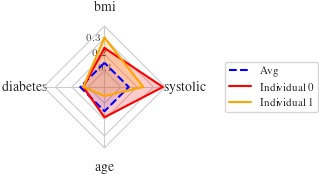

0.055*age**2 + 0.173*age + 0.031*bmi**2 + 0.114*bmi + 0.743*diabetes + 0.046*systolic**2 + 0.155*systolic - 1.871


In [21]:
y = 'ischemia'
x_cols = models['kan_mixed'].parents[y]
n_feats = len(x_cols)
with open(os.path.join(samples_dir, f"cardio_formulas_kaam.pkl"), 'rb') as f:
        formulae = pickle.load(f)

formula_y = formulae[y]

delta_formula, delta_train= get_delta(factual_eval_d[x_cols], formula_y)
delta_train = delta_train[0].iloc[:, :-1]
cols_delta = delta_train.columns

theta = radar_factory(n_feats, frame='polygon')
patient_ids = [0,1]
# set different patient colors: red and orange
colors = ['r', 'orange']
with plt.rc_context({**bundles.iclr2024()}):
    fig, ax = plt.subplots(subplot_kw=dict(projection='radar'), figsize=(5, 2))
    # ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
    avg_delta = sum(np.mean(delta_train, axis=0)) * np.ones(n_feats)

    _ = ax.plot(theta, avg_delta, label='Avg', color='b', linestyle='--')
    ax.fill(theta, avg_delta, alpha=0.1, color='b')

    avg_delta_ = delta_train.mean(axis=0).values[None, :]
    avg_matrix = np.repeat(avg_delta_, delta_train.shape[1], axis=0)

    for j, patient_id in enumerate(patient_ids):
        np.fill_diagonal(avg_matrix, delta_train.iloc[patient_id].values)
        pat_proba = avg_matrix.sum(axis=1)
        _ = ax.plot(theta, pat_proba, label=f'Individual {patient_id}', color=colors[j])
        ax.fill(theta, pat_proba, alpha=0.2, color=colors[j])

    ax.set_varlabels(cols_delta, fontsize=10)
    # legend above the radar plot
    ax.legend(loc='center right', bbox_to_anchor=(2.3, 0.5), ncol=1, fontsize=8)


    formula_text = r'$P(ischemia) = \sigma(0.055 \cdot age**2 + 0.173*age + 0.031\cdot bmi^2 + 0.114\cdot bmi + 0.743\cdot diabetes + 0.046\cdot systolic^2 + 0.155\cdot systolic - 1.871)$'

    plt.tight_layout(rect=[0,0, 0.8, 1])
    plt.savefig(paths.figures / 'ischemia_radar.pdf')
    plt.show()

print(formula_y)

{'figure.figsize': (5.5, 3.399186938124422),
 'figure.constrained_layout.use': True,
 'figure.autolayout': False,
 'savefig.pad_inches': 0.015}

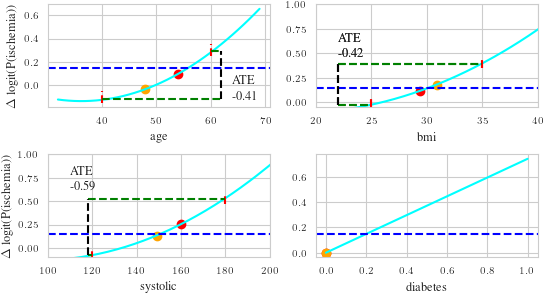

In [62]:
from tueplots import figsizes

with plt.rc_context({**bundles.iclr2024(), **figsizes.iclr2024(ncols=2, nrows=2)}):
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(5.5, 3))

    for i, var in enumerate(x_cols):
        row = i // 2
        col = i % 2
        ax = axs[row, col]


        # plot the value of delta_train[var] against x_train_df[var] ordered with plot
        sorted_idx = np.argsort(factual_eval_d[var])
        x_values = factual_eval_d[var].values[sorted_idx]
        if node_info[var]['type'] == 'continuous':
            x_values = x_values * node_info[var]['std'] + node_info[var]['mean']
        ax.plot(x_values, delta_train[var].values[sorted_idx], color='cyan')

        ax.axhline(y=avg_delta[0], color='b', linestyle='--', label='Avg')

        ax.set_xlabel(var)
        ax.set_ylabel(r'$\Delta$ logit(P(ischemia))')


        # represent the points of the patients of patients_id
        for j, patient_id in enumerate(patient_ids):
            x_point = factual_eval_d[var].values[patient_id]
            if node_info[var]['type'] == 'continuous':
                x_point = x_point * node_info[var]['std'] + node_info[var]['mean']
            ax.scatter(x_point, delta_train[var].values[patient_id], color=colors[j], label=f'Individual {patient_id}')
    axs[0,1].set_ylabel('')
    axs[1,1].set_ylabel('')

    axs[0,1].set_xlim([20,40])
    axs[0,1].set_ylim([-0.05, 1])
    axs[1,0].set_xlim([100,200])
    axs[1,0].set_ylim([-0.1, 1])

    axs[0,0].plot([60, 60], [0.25, 0.35] , color='r', linestyle='--')
    axs[0,0].plot([40, 40], [-0.15, -0.05], color='r', linestyle='--')
    axs[0,0].plot([60, 62], [0.29, 0.29], color='g', linestyle='--')
    axs[0,0].plot([40, 62], [-0.12, -0.12], color='g', linestyle='--')
    axs[0,0].plot([62, 62], [-0.12, 0.29], color='k', linestyle='--')
    axs[0,0].text(64, 0.02, 'ATE')
    axs[0,0].text(64, -0.12, '-0.41')

    axs[0,1].plot([35, 35], [0.35, 0.45] , color='r', linestyle='--')
    axs[0,1].plot([25, 25], [-0.05, 0.05], color='r', linestyle='--')
    axs[0,1].plot([22, 35], [0.39, 0.39], color='g', linestyle='--')
    axs[0,1].plot([22, 25], [-0.03, -0.03], color='g', linestyle='--')
    axs[0,1].plot([22, 22], [-0.03, 0.39], color='k', linestyle='--')
    axs[0,1].text(22, 0.62, 'ATE')
    axs[0,1].text(22, 0.47, '-0.42')

    axs[0,1].plot([35, 35], [0.35, 0.45] , color='r', linestyle='--')
    axs[0,1].plot([25, 25], [-0.05, 0.05], color='r', linestyle='--')
    axs[0,1].plot([22, 35], [0.39, 0.39], color='g', linestyle='--')
    axs[0,1].plot([22, 25], [-0.03, -0.03], color='g', linestyle='--')
    axs[0,1].plot([22, 22], [-0.03, 0.39], color='k', linestyle='--')
    axs[0,1].text(22, 0.62, 'ATE')
    axs[0,1].text(22, 0.47, '-0.42')

    axs[1,0].plot([180, 180], [0.47, 0.57] , color='r', linestyle='--')
    axs[1,0].plot([120, 120], [-0.12, -0.02], color='r', linestyle='--')
    axs[1,0].plot([118, 180], [0.52, 0.52], color='g', linestyle='--')
    axs[1,0].plot([118, 120], [-0.07, -0.07], color='g', linestyle='--')
    axs[1,0].plot([118, 118], [-0.07, 0.52], color='k', linestyle='--')
    axs[1,0].text(110, 0.78, 'ATE')
    axs[1,0].text(110, 0.62, '-0.59')


    plt.savefig(paths.figures / 'ischemia_pdp.pdf')
    plt.show()

0.359*age + 0.284*bmi + 0.028


C:\Users\Alex\AppData\Local\Temp\ipykernel_30136\3649754327.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


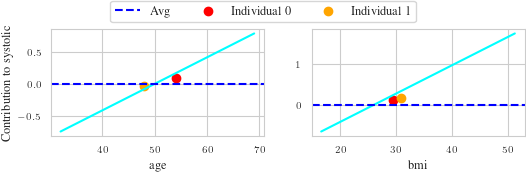

In [29]:
y2 = 'systolic'
x_cols2 = models['kan_mixed'].parents[y2]
n_feats2 = len(x_cols2)

formula_y2 = formulae[y2]
print(formula_y2)

delta_formula2, delta_train2= get_delta(factual_eval_d[x_cols], formula_y2)
delta_train2 = delta_train2[0].iloc[:, :-1]
cols_delta2 = delta_train2.columns
# ax.set_rgrids([0.2, 0.4, 0.6, 0.8])


avg_delta2 = sum(np.mean(delta_train2 , axis=0)) * np.ones(n_feats2)
with plt.rc_context({**bundles.iclr2024(), **figsizes.iclr2024(ncols=2, nrows=1)}):
    fig, axs = plt.subplots(nrows=1, ncols=2)

    for i, var in enumerate(x_cols2):
        col = i % 2
        ax = axs[col]

        # plot the value of delta_train[var] against x_train_df[var] ordered with plot
        sorted_idx = np.argsort(factual_eval_d[var])
        x_values = factual_eval_d[var].values[sorted_idx]
        if node_info[var]['type'] == 'continuous':
            x_values = x_values * node_info[var]['std'] + node_info[var]['mean']
        ax.plot(x_values, delta_train2[var].values[sorted_idx], color='cyan')
        # change the name var (format x25) to latex version x_{25}

        ax.set_xlabel(var)
        ax.set_ylabel(r'Contribution to systolic')
        ax.axhline(y=avg_delta2[0], color='b', linestyle='--', label='Avg')

        # represent the points of the patients of patients_id
                # represent the points of the patients of patients_id
        for j, patient_id in enumerate(patient_ids):
            x_point = factual_eval_d[var].values[patient_id]
            if node_info[var]['type']=='continuous':
                x_point = x_point * node_info[var]['std'] + node_info[var]['mean']
            ax.scatter(x_point, delta_train[var].values[patient_id], color=colors[j], label=f'Individual {patient_id}')

    # plt.savefig('../visualization/pdps_skaam.pdf')
    axs[1].set_ylabel('')
    axs[0].legend()
    handles, labels = axs[0].get_legend_handles_labels()
    axs[0].legend().remove()
        # single legend above the plots with frame
    fig.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=3,
        fontsize= 'medium',
        frameon=True
    )

    formula_systolic_text = r'$-0.028\cdot age^2 - 0.073\cdot age + 0.082\cdot bmi^2 + 0.256\cdot bmi + 0.02$'

    plt.tight_layout()
    plt.savefig(paths.figures / 'systolic_formula.pdf', dpi=300, bbox_inches="tight" )
    plt.show()

In [6]:
# Load and print the results
model_names = ['kan_mixed', 'kaam_mixed', 'kan', 'kaam', 'anm', 'dbcm', 'flow']  # Models used for evaluation
model_name = model_names + ['kaam_mixed_pruned', 'kaam_mixed_symbolic']
metrics = ['rf_acc_obs', 'mmd_obs']  # Metrics used for evaluation
n = len(factual_eval_d)  # Number of samples used for evaluation

results_table_all = []  # Dataset, n, metrics and times per model
names_not_kaam = ['training_time', 'model'] + [m + '_avg' for m in metrics] + ['rf_acc_int_all', 'mmd_int_all']  # Names of results that are not node-specific and not KAAM-specific

for i_m, model_name in enumerate(model_names):
    results_file = os.path.join(data_dir, f"cardio_results_{model_name}.pkl")
    if os.path.exists(results_file):
        with open(results_file, 'rb') as f:
            results = pickle.load(f)
        # Prepare all models summary table
        results_table_all.append([model_name] + [results[m + '_avg'] for m in metrics] + [results['training_time']])
    else:
        print(f"Results file {results_file} not found.")
print('\n\n Average results per dataset (all models):')
print(tabulate(results_table_all, headers=['model'] + metrics + ['Time '], floatfmt=".4f", tablefmt="fancy_grid"))




 Average results per dataset (all models):
╒════════════╤══════════════╤═══════════╤══════════╕
│ model      │   rf_acc_obs │   mmd_obs │    Time  │
╞════════════╪══════════════╪═══════════╪══════════╡
│ kan_mixed  │       0.7545 │    0.0074 │ 126.9435 │
├────────────┼──────────────┼───────────┼──────────┤
│ kaam_mixed │       0.7681 │    0.0076 │ 118.7540 │
├────────────┼──────────────┼───────────┼──────────┤
│ kan        │       0.8224 │    0.0163 │   8.3597 │
├────────────┼──────────────┼───────────┼──────────┤
│ kaam       │       0.8235 │    0.0180 │  42.0818 │
├────────────┼──────────────┼───────────┼──────────┤
│ anm        │       0.8122 │    0.0080 │   0.0288 │
├────────────┼──────────────┼───────────┼──────────┤
│ dbcm       │       0.7715 │    0.0037 │ 120.1336 │
├────────────┼──────────────┼───────────┼──────────┤
│ flow       │       0.7941 │    0.0034 │   2.8926 │
╘════════════╧══════════════╧═══════════╧══════════╛


In [ ]:
# Show the distributions of observational samples for all models compared to the factual data
nodes = factual_eval_d.columns
plt.subplots(len(model_names), len(nodes), figsize=(5 * len(nodes), 5 * len(model_names)))
for i, node in enumerate(nodes):
    for j, model_name in enumerate(model_names):
        obs_model = pd.read_csv(os.path.join(samples_dir, f"cardio_obs_samples_{model_name}.csv"))
        plt.subplot(len(model_names), len(nodes), j * len(nodes) + i + 1)
        plt.hist([factual_eval_d[node], obs_model[node]], bins=30, label=['Factual', 'Model'], alpha=0.7)
        plt.title(f'{model_name} - {node}')
        plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Put one example of the distributions of observational, interventional and counterfactual samples for one dataset and n, for all models
interventions = [('age', 1.0)]
n = len(factual_eval_d)  # Number of samples used for evaluation
model_names = ['kan_mixed', 'kaam_mixed', 'kan', 'kaam', 'anm', 'dbcm', 'flow']  # Models used for evaluation

for model_name in model_names:
    obs_model = pd.read_csv(os.path.join(samples_dir, f"cardio_obs_samples_{model_name}.csv"))
    with open(os.path.join(data_dir, f'cardio_interventional_eval_{model_name}.pkl'), 'rb') as f:
        results_int = pickle.load(f)
    nodes = factual_eval_d.columns

    obs_model['hue'] = 'obs'

    for node, value in interventions:
        # Find in inter_vector the (node, value) pair that matches this
        cf_gt = None
        int_model = None
        cf_model = None
        for node_, value_, d_ in results_int:
            if node == node_ and np.abs(value - value_) < 1e-3:
                int_model = d_

        int_model['hue'] = f'int'
        # Add a little noise to the intervened variables, done to prevent errors in KDE
        int_model[node] += 0.01 * np.random.randn(len(int_model))
        data = pd.concat([obs_model, int_model], ignore_index=True)

        g = sns.PairGrid(data, hue='hue')
        g.map_upper(plt.scatter, alpha=0.1)
        g.map_lower(sns.kdeplot, common_norm=False)
        g.map_diag(sns.histplot, kde=True, stat='proportion', common_norm=False, bins=20)
        _ = g.add_legend()

        for i in range(len(nodes)):
            g.diag_axes[i].set_ylim((0, 0.3)) # NOTE: carefully adjust this to obtain meaningful plots, i.e., the intervention, being discrete, causes a mess

        g.figure.suptitle(f'{model_name} - Intervention node {node} = {value}', y=1.08)
        plt.show()


Extracted formula for node age using KAAM mixed model: N/A
Extracted formula for node age using KAAM model: N/A
Extracted formula for node bmi using KAAM mixed model: -0.0254*age**2 + 0.0899*age + 0.0196
Extracted formula for node bmi using KAAM model: -0.0034*age**4 - 0.0167*age**3 - 0.0012*age**2 + 0.1002*age - 0.0029


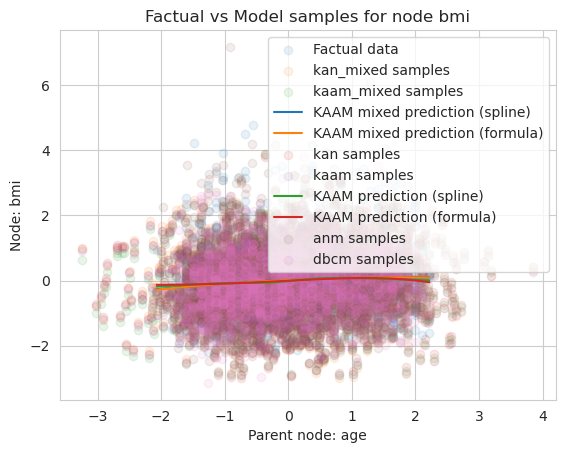

Extracted formula for node cardiac ischemia using KAAM mixed model: 0.0746*age**2 + 0.1933*age - 0.0223*bmi**2 - 0.0485*bmi + 0.306*diabetes_mellitus - 0.0203*systolic_pressure**3 + 0.1253*systolic_pressure**2 + 0.1659*systolic_pressure - 0.9802
Extracted formula for node cardiac ischemia using KAAM model: -0.0067*age**4 - 0.0047*age**3 + 0.0138*age**2 + 0.0253*age + 0.0001*bmi**4 - 0.0013*bmi**3 + 0.0004*bmi**2 + 0.0066*bmi + 0.0001*diabetes_mellitus - 0.e-4*systolic_pressure**3 + 0.0006*systolic_pressure + 0.1599
Extracted formula for node diabetes mellitus using KAAM mixed model: -0.0275*age**2 - 0.038*age + 0.0772*bmi**2 + 0.261*bmi - 1.774
Extracted formula for node diabetes mellitus using KAAM model: -0.0019*age**4 - 0.0013*age**3 + 0.0086*age**2 + 0.0179*age - 0.0002*bmi**4 + 0.0004*bmi**3 + 0.0035*bmi**2 + 0.0123*bmi + 0.0213
Extracted formula for node major acute cardiovascular event using KAAM mixed model: 0.2857*cardiac_ischemia + 2.6972*diabetes_mellitus - 0.9808
Extracted 

In [9]:
model_names = ['kan_mixed', 'kaam_mixed', 'kan', 'kaam', 'anm', 'dbcm', 'flow']

with open(os.path.join(data_dir, f"cardio_results_kaam.pkl"), 'rb') as f:
    results_kaam = pickle.load(f)

with open(os.path.join(data_dir, f"cardio_results_kaam_mixed.pkl"), 'rb') as f:
    results_kaam_mixed = pickle.load(f)

# Go node per node and show how they fit the data and extract the KAAM formulas

for node in factual_eval_d.columns:
    print(f'Extracted formula for node {node} using KAAM mixed model: {results_kaam_mixed.get(f"kaam_formula_{node}", "N/A")}')
    print(f'Extracted formula for node {node} using KAAM model: {results_kaam.get(f"kaam_formula_{node}", "N/A")}')
    if graph_cardio.in_degree(node) == 1:  # Single parent nodes are the ones we are visualizing
        parent_node = list(graph_cardio.predecessors(node))[0]
        plt.scatter(factual_eval_d[parent_node], factual_eval_d[node], label='Factual data', alpha=0.1)
        for model_name in model_names:
            # Get observational samples for the model
            obs_model = pd.read_csv(os.path.join(samples_dir, f"cardio_obs_samples_{model_name}.csv"))
            plt.scatter(obs_model[parent_node], obs_model[node], label=f'{model_name} samples', alpha=0.1)
            if model_name == 'kaam': # Additional info provided by the kaam
                plt.plot(results_kaam[f'x_vals_{node}'], results_kaam[f'kaam_pred_{node}'], label=f'KAAM prediction (spline)')
                plt.plot(results_kaam[f'x_vals_{node}'], results_kaam[f'formula_pred_{node}'], label=f'KAAM prediction (formula)')
            if model_name == 'kaam_mixed': # Additional info provided by the kaam mixed. Note that if the node were discrete, we have logits! (but we plot a single, continuous node in this dataset!)
                plt.plot(results_kaam_mixed[f'x_vals_{node}'], results_kaam_mixed[f'kaam_pred_{node}'], label=f'KAAM mixed prediction (spline)')
                plt.plot(results_kaam_mixed[f'x_vals_{node}'], results_kaam_mixed[f'formula_pred_{node}'], label=f'KAAM mixed prediction (formula)')
        plt.xlabel(f'Parent node: {parent_node}')
        plt.ylabel(f'Node: {node}')
        plt.title(f'Factual vs Model samples for node {node}')
        plt.legend()
        plt.show()

print(f'MAE results for KAAM mixed formulas on SACHS dataset:')
for node in factual_eval_d.columns:
    print(f'Node: {node}, MAE: {results_kaam_mixed.get(f"mae_{node}", "N/A")}')
print(f'Global MAE: {results_kaam_mixed.get("mae", "N/A")}')

print(f'MAE results for KAAM formulas on SACHS dataset:')
for node in factual_eval_d.columns:
    print(f'Node: {node}, MAE: {results_kaam.get(f"mae_{node}", "N/A")}')
print(f'Global MAE: {results_kaam.get("mae", "N/A")}')


 Parents of child node bmi: {'age'}; we will compute interventions on age.
Full formula for Estimated Treatmen Effect (value) of node bmi using KAAM mixed model: -0.0674*age**2 + 0.0615*age + 0.0579
ATE (value_diff) formula estimated for child node bmi using KAAM mixed model when intervening on node age with values (0.0, 1.0): -0.00589752197265625
Full formula for Estimated Treatmen Effect (value) of node bmi using KAAM model: -0.0699*age**2 + 0.0618*age + 0.0602
ATE formula estimated for child node bmi using KAAM model when intervening on node age with values (0.0, 1.0): -0.00810241699218750


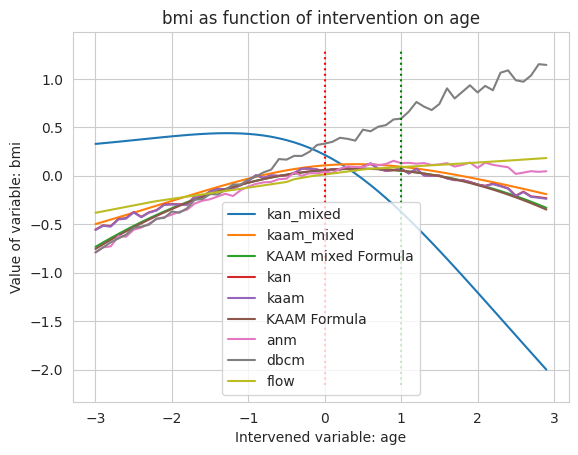

╒═══════════════╤══════════════╤════════════════════╤═════════════╤════════════╕
│ Parent node   │ Child node   │ Model              │   ATE Model │ ATE Type   │
╞═══════════════╪══════════════╪════════════════════╪═════════════╪════════════╡
│ age           │ bmi          │ kan_mixed          │     -0.5890 │ value_diff │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────┤
│ age           │ bmi          │ kaam_mixed         │     -0.0143 │ value_diff │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────┤
│ age           │ bmi          │ KAAM mixed formula │     -0.0059 │ value_diff │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────┤
│ age           │ bmi          │ kan                │      0.0301 │ value_diff │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────┤
│ age           │ bmi          │ kaam               │      0.0295 │ value_diff │
├───────────────┼───────────

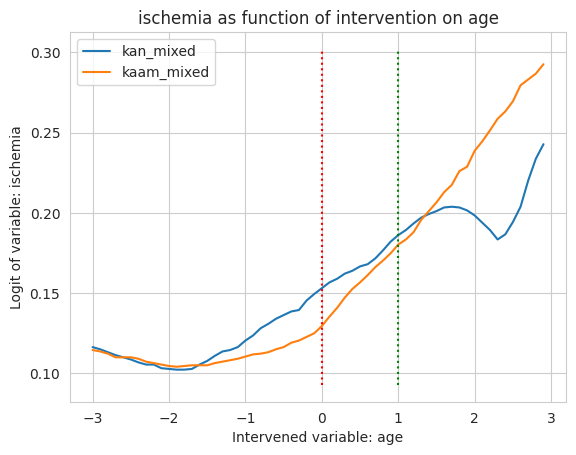

Full formula for Estimated Treatmen Effect (value) of node ischemia using KAAM model: 0.0403*age + 0.0279*bmi + 0.1424*diabetes + 0.033*systolic + 0.1523
ATE formula estimated for child node ischemia using KAAM model when intervening on node age with values (0.0, 1.0): 0.0402984619140625


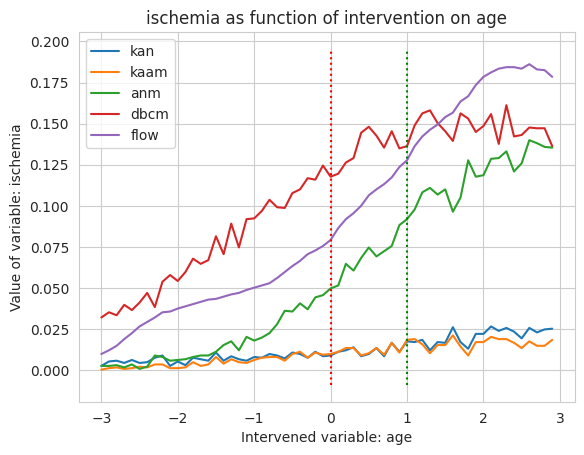

╒═══════════════╤══════════════╤════════════════════╤═════════════╤════════════════╕
│ Parent node   │ Child node   │ Model              │   ATE Model │ ATE Type       │
╞═══════════════╪══════════════╪════════════════════╪═════════════╪════════════════╡
│ age           │ ischemia     │ kan_mixed          │      0.0331 │ log_odds_ratio │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ age           │ ischemia     │ kaam_mixed         │      0.0507 │ log_odds_ratio │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ age           │ ischemia     │ KAAM mixed formula │      0.2679 │ log_odds_ratio │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ age           │ ischemia     │ kan                │      0.0086 │ value_diff     │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ age           │ ischemia     │ kaam               │      0.0086

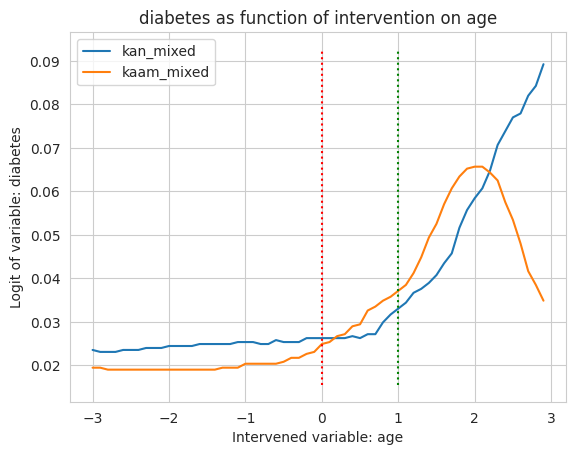

Full formula for Estimated Treatmen Effect (value) of node diabetes using KAAM model: 0.0169*age + 0.0046*bmi**2 + 0.0093*bmi + 0.0246
ATE formula estimated for child node diabetes using KAAM model when intervening on node age with values (0.0, 1.0): 0.0168991088867188


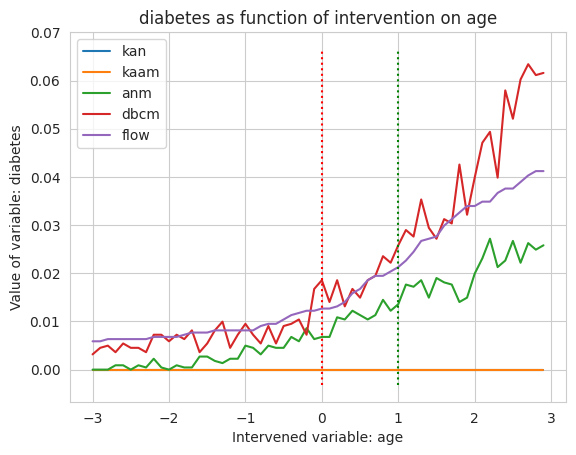

╒═══════════════╤══════════════╤════════════════════╤═════════════╤════════════════╕
│ Parent node   │ Child node   │ Model              │   ATE Model │ ATE Type       │
╞═══════════════╪══════════════╪════════════════════╪═════════════╪════════════════╡
│ age           │ diabetes     │ kan_mixed          │      0.0068 │ log_odds_ratio │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ age           │ diabetes     │ kaam_mixed         │      0.0122 │ log_odds_ratio │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ age           │ diabetes     │ KAAM mixed formula │     -0.0655 │ log_odds_ratio │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ age           │ diabetes     │ kan                │      0.0000 │ value_diff     │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ age           │ diabetes     │ kaam               │      0.0000

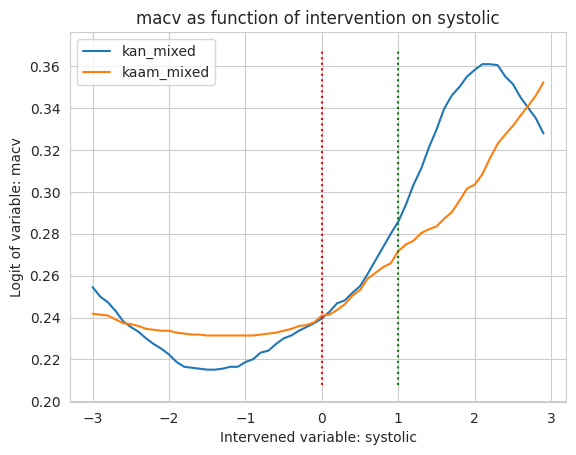

Full formula for Estimated Treatmen Effect (value) of node macv using KAAM model: 0.1927*diabetes + 0.7996*ischemia + 0.1272
ATE formula estimated for child node macv using KAAM model when intervening on node systolic with values (0.0, 1.0): 0


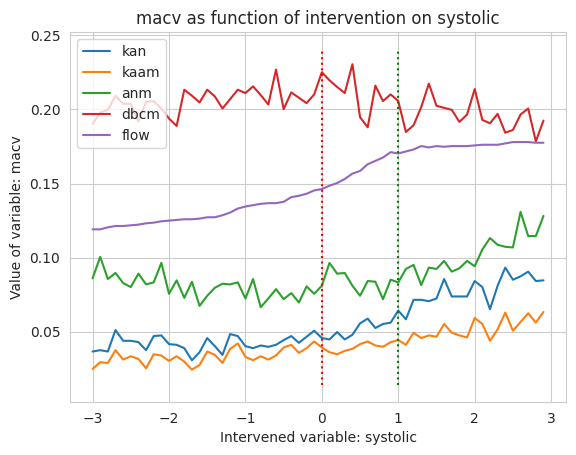

╒═══════════════╤══════════════╤════════════════════╤═════════════╤════════════════╕
│ Parent node   │ Child node   │ Model              │   ATE Model │ ATE Type       │
╞═══════════════╪══════════════╪════════════════════╪═════════════╪════════════════╡
│ systolic      │ macv         │ kan_mixed          │      0.0462 │ log_odds_ratio │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ systolic      │ macv         │ kaam_mixed         │      0.0308 │ log_odds_ratio │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ systolic      │ macv         │ KAAM mixed formula │      0.0000 │ log_odds_ratio │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ systolic      │ macv         │ kan                │      0.0186 │ value_diff     │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────────┤
│ systolic      │ macv         │ kaam               │      0.0050

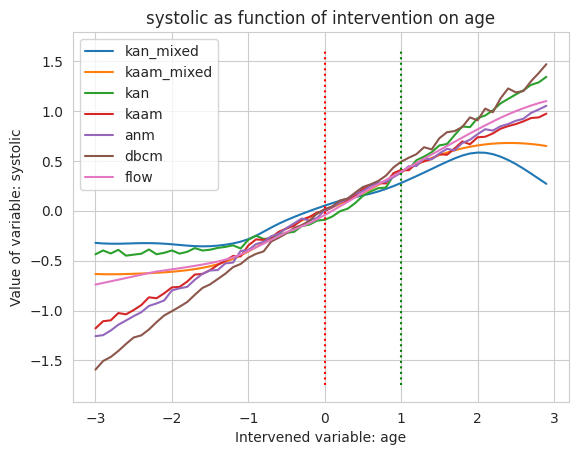

╒═══════════════╤══════════════╤════════════════════╤═════════════╤════════════╕
│ Parent node   │ Child node   │ Model              │   ATE Model │ ATE Type   │
╞═══════════════╪══════════════╪════════════════════╪═════════════╪════════════╡
│ age           │ systolic     │ kan_mixed          │      0.2275 │ value_diff │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────┤
│ age           │ systolic     │ kaam_mixed         │      0.3816 │ value_diff │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────┤
│ age           │ systolic     │ KAAM mixed formula │      0.3596 │ value_diff │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────┤
│ age           │ systolic     │ kan                │      0.4948 │ value_diff │
├───────────────┼──────────────┼────────────────────┼─────────────┼────────────┤
│ age           │ systolic     │ kaam               │      0.4129 │ value_diff │
├───────────────┼───────────

In [11]:
# ATE example on a single variable: formula vs each model
# First, we obtain the nodes that are descendents of the intervened node
intervention_values = (0.0, 1.0) # intervention value 0, intervention value 1 (note that we use these values se they are valid for binary and continuous variables!)
model_names = ['kan_mixed', 'kaam_mixed', 'kan', 'kaam', 'anm', 'dbcm', 'flow']

results_file = os.path.join(data_dir, f"cardio_results_kaam.pkl") # KAAM results file to extract formulas
with open(results_file, 'rb') as f:
    results_kaam = pickle.load(f)

results_file = os.path.join(data_dir, f"cardio_results_kaam_mixed.pkl") # KAAM results file to extract formulas
with open(results_file, 'rb') as f:
    results_kaam_mixed = pickle.load(f)

binary_nodes = [node for node in factual_train_d.columns if node_info[node]['type'] == 'discrete']



for child_node in factual_eval_d.columns:
    n_parents = graph_cardio.in_degree(child_node)
    ate_table = []
    if n_parents > 0:  # Only when there exists at least a parent!
        parent_nodes = nx.ancestors(graph_cardio, child_node)
        parent_node = f'{list(parent_nodes)[0]}'  # We will only plot results intervening on the first parent to show the potential of using KAAMs
        print(f' Parents of child node {child_node}: {parent_nodes}; we will compute interventions on {parent_node}.')
        parent_int_values = {'kaam_formula': None, 'kaam_ate_formula': None, parent_node: {}}
        for ml in [('kan_mixed', 'kaam_mixed'), ('kan', 'kaam', 'anm', 'dbcm', 'flow')]:
            for model_name in ml:  # We are using separate plots for mixed and non-mixed models!
                if 'mixed' in model_name and node_info[child_node]['type'] == 'discrete':
                    ate_type = 'log_odds_ratio'
                    et_type = 'logit'
                else:
                    ate_type = 'value_diff'
                    et_type = 'value'
                with open(os.path.join(data_dir, f'cardio_interventional_eval_{model_name}.pkl'), 'rb') as f:
                    int_samples_vector = pickle.load(f)
                for node_, value_, d_ in int_samples_vector:
                    if parent_node == node_:
                        if np.abs(value_ - intervention_values[0]) < 1e-3:
                            parent_int_values[parent_node][f'cf_{model_name}_0'] = d_[child_node]
                        if np.abs(value_ - intervention_values[1]) < 1e-3:
                            parent_int_values[parent_node][f'cf_{model_name}_1'] = d_[child_node]
                parent_int_values[parent_node][f'{model_name}_ate'] = np.mean(parent_int_values[parent_node][f'cf_{model_name}_1'].to_numpy()) -  np.mean(parent_int_values[parent_node][f'cf_{model_name}_0'].to_numpy())
                ate_table.append([parent_node, child_node, model_name, parent_int_values[parent_node][f'{model_name}_ate'], ate_type])

                if model_name == 'kaam':
                    # Now, create a symbolic function using the formulas extracted by KAAM
                    child_node_formula = results_kaam.get(f'kaam_formula_{child_node}', None)
                    if child_node_formula is None:
                        print(f'No formula for node {child_node} in KAAM model')
                    else:
                        parent_int_values['kaam_formula'] = child_node_formula
                        kaam_ate_formula = child_node_formula.subs(parent_node, intervention_values[1]) - child_node_formula.subs(parent_node, intervention_values[0])  # Note that we intervene always only on the first parent!
                        parent_int_values['kaam_ate_formula'] = kaam_ate_formula
                        print(f'Full formula for Estimated Treatmen Effect ({et_type}) of node {child_node} using KAAM model: {child_node_formula}')
                        print(f'ATE formula estimated for child node {child_node} using KAAM model when intervening on node {parent_node} with values {intervention_values}: {kaam_ate_formula}')
                        ate_formula_kaam = float(kaam_ate_formula)
                        ate_table.append([parent_node, child_node, 'KAAM formula', ate_formula_kaam, ate_type])

                if model_name == 'kaam_mixed':
                    # Now, create a symbolic function using the formulas extracted by KAAM mixed
                    child_node_formula = results_kaam_mixed.get(f'kaam_formula_{child_node}', None)
                    if child_node_formula is None:
                        print(f'No formula for node {child_node} in KAAM mixed model')
                    else:
                        parent_int_values['kaam_mixed_formula'] = child_node_formula
                        if node_info[child_node]['type'] == 'discrete': # Return ATE as log odds ratio!! (diff in logits!)
                            kaam_mixed_ate_formula = child_node_formula.subs(parent_node, intervention_values[1]) - child_node_formula.subs(parent_node, intervention_values[0])
                        else:
                            kaam_mixed_ate_formula = child_node_formula.subs(parent_node, intervention_values[1]) - child_node_formula.subs(parent_node, intervention_values[0])  # Note that we intervene always only on the first parent!
                        parent_int_values['kaam_mixed_ate_formula'] = kaam_mixed_ate_formula
                        print(f'Full formula for Estimated Treatmen Effect ({et_type}) of node {child_node} using KAAM mixed model: {child_node_formula}')
                        print(f'ATE ({ate_type}) formula estimated for child node {child_node} using KAAM mixed model when intervening on node {parent_node} with values {intervention_values}: {kaam_mixed_ate_formula}')
                        ate_formula_kaam = float(kaam_mixed_ate_formula)
                        ate_table.append([parent_node, child_node, 'KAAM mixed formula', kaam_mixed_ate_formula, ate_type])

                # Now, plot the expected effect formula
                int_vals_ordered = []
                for value_o in node_info[parent_node]['int_values']:
                    for node_, value_, d_ in int_samples_vector:
                        if parent_node == node_ and np.abs(value_ - value_o) < 1e-3:
                            int_vals_ordered.append(np.mean(d_[child_node].to_numpy()))
                int_vals_ordered = np.array(int_vals_ordered)
                plt.plot(node_info[parent_node]['int_values'], int_vals_ordered, label=model_name)

                if model_name == 'kaam' and n_parents == 1:  # We can only plot this for single parent KAAMs
                    kaam_int_vals = []
                    for x in node_info[parent_node]['int_values']:
                        int_val_kaam = parent_int_values['kaam_formula'].subs(parent_node, x)
                        kaam_int_vals.append(float(int_val_kaam))
                    plt.plot(node_info[parent_node]['int_values'], kaam_int_vals, label='KAAM Formula')

                if model_name == 'kaam_mixed' and n_parents == 1:  # We can only plot this for single parent KAAMs
                    kaam_int_vals = []
                    for x in node_info[parent_node]['int_values']:
                        int_val_kaam = parent_int_values['kaam_mixed_formula'].subs(parent_node, x)
                        kaam_int_vals.append(float(int_val_kaam))
                    kaam_int_vals = np.array(kaam_int_vals)
                    if node_info[child_node]['type'] == 'discrete':
                        plt.plot(node_info[parent_node]['int_values'], kaam_int_vals, label='KAAM mixed Formula')
                    else:
                        plt.plot(node_info[parent_node]['int_values'], kaam_int_vals, label='KAAM mixed Formula')
            plt.xlabel(f'Intervened variable: {parent_node}')
            if 'mixed' in model_name and node_info[child_node]['type'] == 'discrete':
                plt.ylabel(f'Logit of variable: {child_node}')
            else:
                plt.ylabel(f'Value of variable: {child_node}')
            plt.title(f'{child_node} as function of intervention on {parent_node}')
            plt.legend()
            if 'mixed' in model_name and node_info[child_node]['type'] == 'continuous': # In this case, do not show yet, to plot all models together--if discrete, do separate plots
                pass
            else:
                y_min, y_max = plt.ylim()
                plt.vlines(intervention_values[0], ymin=y_min, ymax=y_max, color='red', linestyle=':', label=f'Treatment 0')
                plt.vlines(intervention_values[1], ymin=y_min, ymax=y_max, color='green', linestyle=':', label=f'Treatment 1')
                plt.show()

        print(tabulate(ate_table,headers=['Parent node', 'Child node', 'Model', 'ATE Model', 'ATE Type'], floatfmt=".4f", tablefmt="fancy_grid"))

No KAAM formula for node age
No KAAM mixed formula for node age


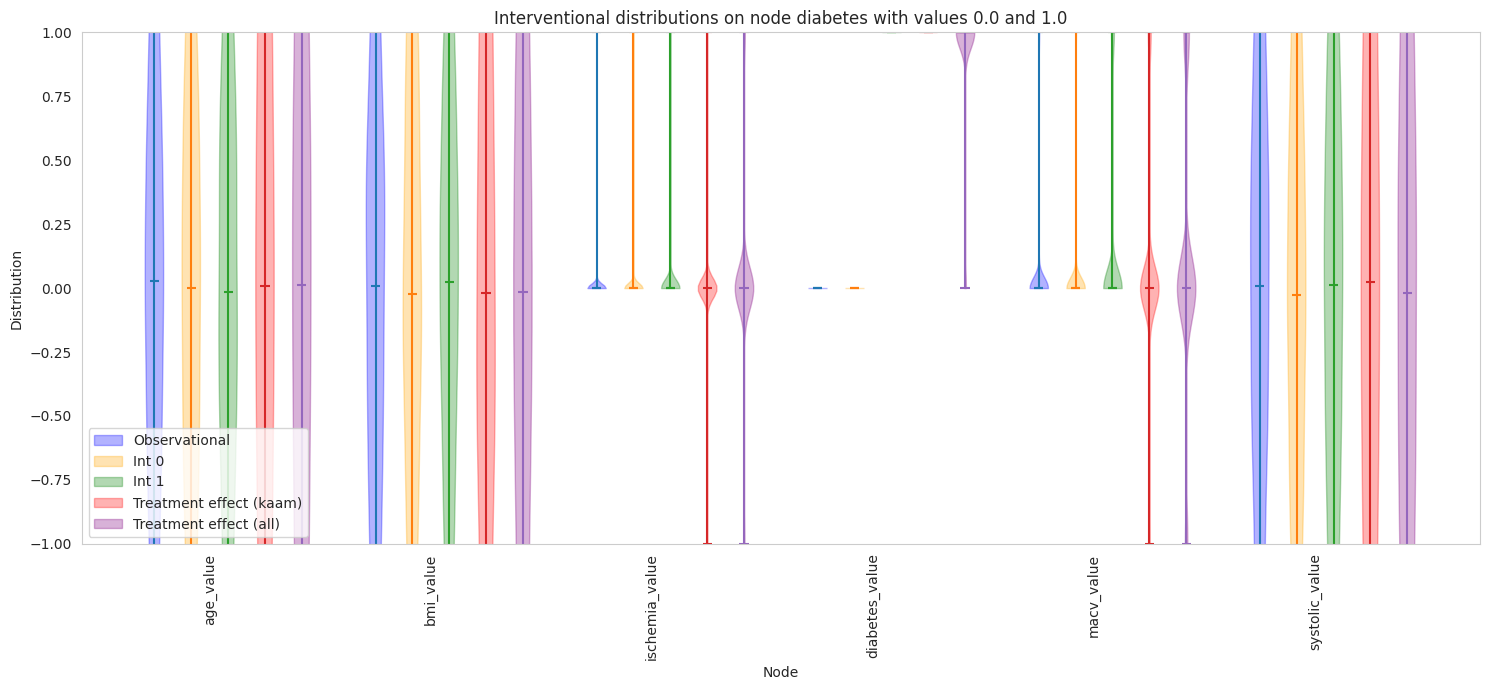

ATE estimated for the intervention in node diabetes with values 0.0 and 1.0
               kan      kaam      dbcm       anm      flow   ATE_types
age      -0.001316 -0.001316  0.049847 -0.023717  0.000000  value_diff
bmi       0.004921  0.004982  0.019252 -0.011012  0.000000  value_diff
ischemia  0.009964  0.018116 -0.022645  0.086957  0.039402  value_diff
diabetes  1.000000  1.000000  1.000000  1.000000  0.569293  value_diff
macv      0.166214  0.095562  0.111866  0.148551  0.055254  value_diff
systolic  0.017875  0.025995  0.037383  0.065676  0.000000  value_diff
List of children nodes of diabetes: ['ischemia', 'macv']
KAAM formula (value) for child node ischemia: 0.0403*age + 0.0279*bmi + 0.1424*diabetes + 0.033*systolic + 0.1523
KAAM ATE (value diff) by formula on node ischemia when diabetes takes values 0.0 and 1.0: 0.142400741577148
KAAM mixed formula (logit) for child node ischemia: 0.0746*age**2 + 0.1933*age - 0.0223*bmi**2 - 0.0485*bmi + 0.306*diabetes - 0.0203*systolic**3 + 

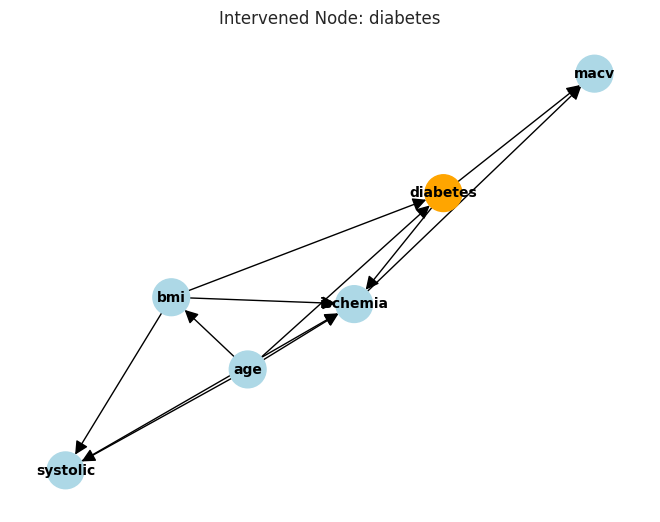

interactive(children=(Dropdown(description='Model:', options=('kan_mixed', 'kaam_mixed', 'kan', 'kaam', 'anm',…

<function __main__.plot_function(model, node, value0, value1)>

In [39]:
# Create a dropdown for selecting the node we want to intervene on
model_names = ['kan_mixed', 'kaam_mixed', 'kan', 'kaam', 'anm', 'dbcm', 'flow']

model_dropdown = widgets.Dropdown(
    options=model_names,
    value=model_names[0],
    description='Model:',
)

node_dropdown = widgets.Dropdown(
    options=list(graph_cardio.nodes),
    value='age',
    description='Intervened Node:',
)
# Create sliders for selecting intervention values
cf_value0_slider = widgets.FloatSlider(
    value=0.0,
    min=int_min_val, # These values actually depend on child_node and are: node_info[child_node][int_values]
    max=int_max_val,
    step=int_step,
    description='Int Value 0',
)

cf_value1_slider = widgets.FloatSlider(
    value=1.0,
    min=int_min_val,
    max=int_max_val,
    step=int_step,
    description='CF Value 1',
)
cf_results_all = {}
for model_name in model_names:
    with open(os.path.join(data_dir, f'cardio_interventional_eval_{model_name}.pkl'), 'rb') as f:
        results_cf = pickle.load(f)
    cf_results_all[model_name] = deepcopy(results_cf)

obs_model_all = {}
for model_name in model_names:
    obs_model = pd.read_csv(os.path.join(samples_dir, f"cardio_obs_samples_{model_name}.csv"))
    obs_model_all[model_name] = deepcopy(obs_model)

results_file = os.path.join(data_dir, f"cardio_results_kaam.pkl") # KAAM results file to extract formulas
with open(results_file, 'rb') as f:
    results_kaam = pickle.load(f)

results_file = os.path.join(data_dir, f"cardio_results_kaam_mixed.pkl") # KAAM results file to extract formulas
with open(results_file, 'rb') as f:
    results_kaam_mixed = pickle.load(f)


all_formulae = {}
for child_node in factual_eval_d.columns:
    all_formulae[child_node] = {}
    child_node_formula = results_kaam.get(f'kaam_formula_{child_node}', None)
    if child_node_formula is None:
        print(f'No KAAM formula for node {child_node}')
    all_formulae[child_node]['kaam'] = deepcopy(child_node_formula)
    child_node_formula = results_kaam_mixed.get(f'kaam_formula_{child_node}', None)
    if child_node_formula is None:
        print(f'No KAAM mixed formula for node {child_node}')
    all_formulae[child_node]['kaam_mixed'] = deepcopy(child_node_formula)

pos = nx.spring_layout(graph_cardio)  # Use the same layout always

def plot_function(model, node, value0, value1):
    cf_model_0 = None
    cf_model_1 = None
    for node_, value_, d_ in cf_results_all[model]:
        if node_ == node:
            if np.abs(value_ - value0) < 1e-3:
                cf_model_0 = d_
            if np.abs(value_ - value1) < 1e-3:
                cf_model_1 = d_
    ate_all = {}
    cf_all_0 = []
    cf_all_1 = []
    if 'mixed' in model:
        other_models = ['kan_mixed', 'kaam_mixed']  # Only use mixed models to compare properly (i.e., in discrete variables, to have logits)
    else:
        other_models = ['kan', 'kaam', 'dbcm', 'anm', 'flow']
    for m in other_models:
        for node_, value_, d_ in cf_results_all[m]:
            if node_ == node:
                if np.abs(value_ - value0) < 1e-3:
                    cf_all_0.append(d_)
                if np.abs(value_ - value1) < 1e-3:
                    cf_all_1.append(d_)
        ate_all[m] = cf_all_1[-1].mean() - cf_all_0[-1].mean()
    cf_all_0 = pd.concat(cf_all_0, axis=0)
    cf_all_1 = pd.concat(cf_all_1, axis=0)
    # Keep a random subset of samples to prevent slowing down the plot
    cf_all_0 = cf_all_0.sample(frac=1 / len(model_names)).reset_index(drop=True)
    cf_all_1 = cf_all_1.sample(frac=1 / len(model_names)).reset_index(drop=True)

    # Plot a large boxplot, including all variables and their values
    nodes = factual_eval_d.columns
    if 'mixed' in model:
        nodes_names = [n + f'_value' if node_info[n]['type'] == 'continuous' else n + f'_logit' for n in nodes]
    else:
        nodes_names = [n + f'_value' for n in nodes]
    positions = np.arange(len(nodes)) * 6
    plt.figure(figsize=(15, 7))
    vp1 = plt.violinplot([obs_model_all[model][node] for node in nodes], positions=positions, showmedians=True)
    for body in vp1['bodies']:
        body.set_color('b')
    vp2 = plt.violinplot([cf_model_0[node] for node in nodes], positions=positions + 1, showmedians=True)
    for body in vp2['bodies']:
        body.set_color('orange')
    vp3 = plt.violinplot([cf_model_1[node] for node in nodes], positions=positions + 2, showmedians=True)
    for body in vp3['bodies']:
        body.set_color('g')
    vp4 = plt.violinplot([cf_model_1[node] - cf_model_0[node] for node in nodes], positions=positions + 3, showmedians=True)
    for body in vp4['bodies']:
        body.set_color('r')
    vp5 = plt.violinplot([cf_all_1[node] - cf_all_0[node] for node in nodes], positions=positions + 4, showmedians=True)
    for body in vp5['bodies']:
        body.set_color('purple')

    plt.xticks(positions + 1.5, nodes_names, rotation=90)
    plt.xlabel('Node')
    plt.ylabel('Distribution')
    plt.legend([vp1['bodies'][0],vp2['bodies'][0], vp3['bodies'][0], vp4['bodies'][0], vp5['bodies'][0]],['Observational', 'Int 0', 'Int 1', f'Treatment effect ({model})', 'Treatment effect (all)'], loc='best')
    plt.title(f'Interventional distributions on node {node} with values {value0} and {value1}')
    plt.ylim(-1, 1)  # Limit y-axis for better visualization
    plt.grid()
    plt.tight_layout()
    plt.show()

    ate_all_df = pd.DataFrame(ate_all)
    ate_types = []
    for n in ate_all_df.index:
        if node_info[n]['type'] == 'discrete' and 'mixed' in model:
            ate_types.append('log_odd_ratio')
        else:
            ate_types.append('value_diff')
    ate_all_df['ATE_types'] = ate_types
    print(f'ATE estimated for the intervention in node {node} with values {value0} and {value1}')
    print(ate_all_df)

    if 'kaam' in model:
        child_nodes = list(nx.descendants(graph_cardio, node))
        print(f'List of children nodes of {node}: {child_nodes}')
        for child_node in child_nodes:
            child_node_formula = deepcopy(all_formulae[child_node]['kaam'])
            print(f'KAAM formula (value) for child node {child_node}: {child_node_formula}')
            ate_formula = child_node_formula.subs(node, value1) - child_node_formula.subs(node, value0)
            print(f'KAAM ATE (value diff) by formula on node {child_node} when {node} takes values {value0} and {value1}: {ate_formula}')
            if node_info[child_node]['type'] == 'discrete':
                ate_type = 'log_odds_ratio'
                et_type = 'logit'
            else:
                ate_type = 'value'
                et_type = 'value diff'
            child_node_formula = deepcopy(all_formulae[child_node]['kaam_mixed'])
            print(f'KAAM mixed formula ({et_type}) for child node {child_node}: {child_node_formula}')
            ate_formula = child_node_formula.subs(node, value1) - child_node_formula.subs(node, value0)
            print(f'KAAM mixed ATE ({ate_type}) by formula on node {child_node} when {node} takes values {value0} and {value1}: {ate_formula}')

    # Plot the graph highlighting the intervened node
    node_colors = ['lightblue' if n != node else 'orange' for n in graph_cardio.nodes]
    nx.draw(graph_cardio, pos, with_labels=True, node_size=700, node_color=node_colors, font_size=10, font_weight='bold', arrowsize=20)
    plt.title(f'Intervened Node: {node}')
    plt.grid()
    plt.show()

plot_function('kaam', 'diabetes', 0.0, 1.0)

widgets.interact(plot_function, model=model_dropdown, node=node_dropdown, value0=cf_value0_slider, value1=cf_value1_slider)